# Aircraft Track Over Radar Data 

The eventual plan for this code is to have an aircraft track plotted over the duration of the radar data file. This will give an idea of where the UND
citation aircraft was at during a given radar scan and eventually will have a gif creation capability. 

In [1]:
# Libraries
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import imageio.v2 as imageio
import pandas as pd
import time
from datetime import datetime
import cmweather
import numpy as np


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



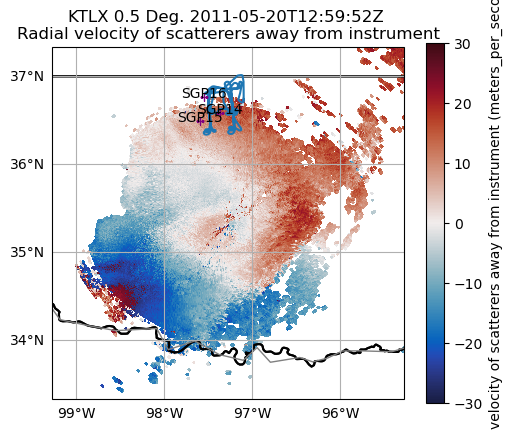

In [38]:
# Flight track over radar data plot
citation_nav = pd.read_csv('flight_data/2011-05-20_CITATION.dat', sep = ',', header = None)
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

# Reflectivity plotting 
filename = 'KTLX20110520_125935_V03.gz'
data = pyart.io.read('KTLX_May_20_2011/' + filename)

display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 2 #subtracting 1.5 degrees lat
max_lat = center_lat + 2 #adding 1.5 degrees lat
min_lon = center_lon - 2 #subtracting 1.5 degrees lon
max_lon = center_lon + 2 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('velocity', 
                            ax = ax,
                            sweep = 1, 
                            cmap = 'balance', 
                            vmin = -30,
                            vmax = 30,
                            min_lon = min_lon, 
                            max_lon = max_lon,
                            min_lat = min_lat,
                            max_lat = max_lat)

# Citation location finder given radar time of scan 


plt.plot(cit_lon, cit_lat)
#SGP16
plt.annotate('SGP16', xy = (-97.5472, 36.7675),ha = 'center')
plt.plot(-97.5472, 36.7675, marker = '+', color = 'purple')
#SGP15
plt.annotate('SGP15', (-97.593889, 36.49111), ha = 'center')
plt.plot(-97.593889, 36.49111, marker = '+', color = 'purple')
#SGP14
plt.annotate('SGP14', (-97.363611, 36.578611), ha = 'center')
plt.plot(-97.363611, 36.578611, marker = '+', color = 'purple')
plt.show()

#\u2708 is the airplane latex code

In [33]:
# Citation location finder given radar scan time. 
filename = 'sgpcsaprsurcmacI7.c0.20110520.143552.nc.v0'
data = pyart.io.read('C-SAPR_May_20_2011/' + filename)

citation_nav = pd.read_csv('flight_data/2011-05-20_CITATION.dat', sep = ',', header = None)
cit_time = citation_nav.iloc[:, 1]
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

time_dif = []
for time in range(len(citation_nav)):
    time_dif.append(abs(datetime.strptime(data.time['units'].split()[2], "%Y-%m-%dT%H:%M:%SZ").timestamp() - datetime.strptime(cit_time[time][0:19], "%Y-%m-%dT%H:%M:%S").timestamp()))

min_time = time_dif.index(min(time_dif))
print(cit_time[min_time])

2011-05-20T14:35:56.017


In [16]:
#===============================================
# This code below will generate radar PPI images
# with citation flight tracks overlayed to then
# be displayed with the RadCAT code that 
# visuallizes all of the data from the flight.
#================================================

# Read in navigation data from citation aircraft
cloud_micro = xr.open_dataset('flight_data/11_05_20_Radar.nc')

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append((int(radar_files[x].name[30:36][0:2]) * 3600) + (int(radar_files[x].name[30:36][2:4]) * 60) + (int(radar_files[x].name[30:36][4:6])))

for file_number in range(len(radar_files)):
    index = np.argmin(abs(np.array(cloud_micro.Time.data) - radar_file_times[file_number]))
    # Code below calculates that theoretical reflectivity value given the aircraft measurement 
    # HVPS particle size distribution plot
    hvps_data = np.array([cloud_micro.HVPS_Ch1.data[index], cloud_micro.HVPS_Ch2.data[index], 
                      cloud_micro.HVPS_Ch3.data[index], cloud_micro.HVPS_Ch4.data[index], 
                      cloud_micro.HVPS_Ch5.data[index], cloud_micro.HVPS_Ch6.data[index], 
                      cloud_micro.HVPS_Ch7.data[index], cloud_micro.HVPS_Ch8.data[index],
                      cloud_micro.HVPS_Ch9.data[index], cloud_micro.HVPS_Ch10.data[index],
                      cloud_micro.HVPS_Ch11.data[index], cloud_micro.HVPS_Ch12.data[index],
                      cloud_micro.HVPS_Ch13.data[index], cloud_micro.HVPS_Ch14.data[index], 
                      cloud_micro.HVPS_Ch15.data[index], cloud_micro.HVPS_Ch16.data[index],
                      cloud_micro.HVPS_Ch17.data[index], cloud_micro.HVPS_Ch18.data[index],
                      cloud_micro.HVPS_Ch19.data[index], cloud_micro.HVPS_Ch20.data[index],
                      cloud_micro.HVPS_Ch21.data[index], cloud_micro.HVPS_Ch22.data[index], 
                      cloud_micro.HVPS_Ch23.data[index], cloud_micro.HVPS_Ch24.data[index],
                      cloud_micro.HVPS_Ch25.data[index], cloud_micro.HVPS_Ch26.data[index], 
                      cloud_micro.HVPS_Ch27.data[index], cloud_micro.HVPS_Ch28.data[index]])

    hvps_bin_sizes = np.array([300, 500, 700, 900, 1100, 
                  1300, 1500, 1700, 2000, 2400, 
                  2800, 3200, 3600, 4000, 4400, 
                  4800, 5500, 6500, 7500, 8500, 
                  9500, 11000, 13000, 15000, 
                  17000, 19000, 22500, 27500])

    hvps_bin_sizes = hvps_bin_sizes * .001 # Convert to mm 
    hvps_bin_sizes = hvps_bin_sizes ** 6 # Convert to D^6 for reflectivity calculation

    reflec_air = hvps_data * hvps_bin_sizes
    reflec_air = reflec_air * 1000000
    reflec_air =  10 * np.log10(reflec_air.sum()) * .19

    # This below find the aircraft sweep for the appropriate PPI map to be created
    data = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[file_number].name)
    vert_radar_profile = pyart.util.columnsect.get_field_location(data, float(cloud_micro.POS_Lat.data[index]), float(cloud_micro.POS_Lon.data[index]))
    sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (float(cloud_micro.POS_Alt.data[index]))))

    
    display = pyart.graph.RadarMapDisplay(data)
    projection = ccrs.PlateCarree()
                        
    fig = plt.figure(figsize = (11,9))
                                    
    # Reflectivity plot
    ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')
                                    
    a = display.plot_ppi_map('corrected_reflectivity_horizontal', 
                        ax = ax,
                        sweep = sweep, 
                        vmin = -30, 
                        vmax = 70,
                        cmap = 'ChaseSpectral') #Variable name
    
    ref_val = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
    cmap_data = plt.colormaps['ChaseSpectral']
    ref_val_norm = (ref_val + 30) / (100)
    point_color = cmap_data(ref_val_norm)

    ax.plot(float(cloud_micro.POS_Lon.data[index]), float(cloud_micro.POS_Lat.data[index]), color = point_color, marker = 'o', markeredgecolor='black')
    
    label = '  Radar reflectivity ' + '\n' + '  ' + str(round(ref_val, 2)) + ' dBz' +  '\n'  + '  Air reflectivity ' + '\n' + '  ' + str(round(reflec_air, 2)) + ' dBz'
    ax.text(float(cloud_micro.POS_Lon.data[index]), float(cloud_micro.POS_Lat.data[index]), label, fontsize=10)
    plt.savefig(f'images/{radar_files[file_number].name}.png')
    plt.close()

In [2]:
cloud_micro = xr.open_dataset('flight_data/11_05_20_Radar.nc')

In [ ]:
for time in range(len(cloud_micro.HVPS_Ch1.data)):
    # HVPS particle size distribution plot
    hvps_data = np.array([cloud_micro.HVPS_Ch1.data[time], cloud_micro.HVPS_Ch2.data[time], cloud_micro.HVPS_Ch3.data[time], cloud_micro.HVPS_Ch4.data[time], 
                 cloud_micro.HVPS_Ch5.data[time], cloud_micro.HVPS_Ch6.data[time], cloud_micro.HVPS_Ch7.data[time], cloud_micro.HVPS_Ch8.data[time],
                 cloud_micro.HVPS_Ch9.data[time], cloud_micro.HVPS_Ch10.data[time], cloud_micro.HVPS_Ch11.data[time], cloud_micro.HVPS_Ch12.data[time],
                 cloud_micro.HVPS_Ch13.data[time], cloud_micro.HVPS_Ch14.data[time], cloud_micro.HVPS_Ch15.data[time], cloud_micro.HVPS_Ch16.data[time],
                 cloud_micro.HVPS_Ch17.data[time], cloud_micro.HVPS_Ch18.data[time], cloud_micro.HVPS_Ch19.data[time], cloud_micro.HVPS_Ch20.data[time],
                 cloud_micro.HVPS_Ch21.data[time], cloud_micro.HVPS_Ch22.data[time], cloud_micro.HVPS_Ch23.data[time], cloud_micro.HVPS_Ch24.data[time],
                 cloud_micro.HVPS_Ch25.data[time], cloud_micro.HVPS_Ch26.data[time], cloud_micro.HVPS_Ch27.data[time], cloud_micro.HVPS_Ch28.data[time]])
    
    hvps_bin_sizes = np.array([300, 500, 700, 900, 1100, 
                      1300, 1500, 1700, 2000, 2400, 
                      2800, 3200, 3600, 4000, 4400, 
                      4800, 5500, 6500, 7500, 8500, 
                      9500, 11000, 13000, 15000, 
                      17000, 19000, 22500, 27500])
    
    hvps_bin_sizes = hvps_bin_sizes * .001 # Convert to mm 
    hvps_bin_sizes = hvps_bin_sizes ** 6 # Convert to D^6 for reflectivity calculation
    
    reflec = hvps_data * hvps_bin_sizes
    reflec = reflec * 1000000
    reflec =  10 * np.log10(reflec.sum()) * .208
    print(reflec)
    print(cloud_micro.Radar_Reflectivity.data[time])
    print()

In [ ]:
# Code below calculates that theoretical reflectivity value given the aircraft measurement 
# HVPS particle size distribution plot
hvps_data = np.array([cloud_micro.HVPS_Ch1.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch2.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch3.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch4.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch5.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch6.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch7.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch8.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch9.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch10.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch11.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch12.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch13.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch14.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch15.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch16.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch17.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch18.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch19.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch20.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch21.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch22.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch23.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch24.sel(Time = float(radar_file_times[file_number]) + .09).data[0],
                  cloud_micro.HVPS_Ch25.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch26.sel(Time = float(radar_file_times[file_number]) + .09).data[0], 
                  cloud_micro.HVPS_Ch27.sel(Time = float(radar_file_times[file_number]) + .09).data[0], cloud_micro.HVPS_Ch28.sel(Time = float(radar_file_times[file_number]) + .09).data[0]])

hvps_bin_sizes = np.array([300, 500, 700, 900, 1100, 
              1300, 1500, 1700, 2000, 2400, 
              2800, 3200, 3600, 4000, 4400, 
              4800, 5500, 6500, 7500, 8500, 
              9500, 11000, 13000, 15000, 
              17000, 19000, 22500, 27500])

hvps_bin_sizes = hvps_bin_sizes * .001 # Convert to mm 
hvps_bin_sizes = hvps_bin_sizes ** 6 # Convert to D^6 for reflectivity calculation

reflec_air = hvps_data * hvps_bin_sizes
reflec_air = reflec_air * 1000000
reflec_air =  10 * np.log10(reflec_air.sum()) * .19